# Descriptive Statistics — News Analyst Ratings
Exploratory analysis covering:
1. Headline character length distribution
2. Articles per publisher
3. Publication volume trends over time

In [ ]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.eda import (
    load_data,
    clean_data,
    headline_length_stats,
    plot_headline_length_distribution,
    articles_per_publisher,
    plot_articles_per_publisher,
    publication_date_trends,
    plot_publication_trends,
    top_publishing_days,
    top_count_terms,
    top_tfidf_terms,
    plot_top_terms,
    financial_phrase_counts,
    plot_financial_phrases,
    lda_topics,
    plot_lda_topics,
    publishing_hour_distribution,
    plot_publishing_hours,
    extract_publisher_domains,
    plot_publisher_domains,
    publisher_coverage_profile,
)

DATA_PATH = 'data/raw/raw_analyst_ratings.csv'
OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
df = load_data(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["date"].min()} → {df["date"].max()}')
df.head()

Shape: (1407328, 7)
Columns: ['headline', 'url', 'publisher', 'date', 'stock', 'pub_date', 'pub_hour']
Date range: 2009-02-14 00:00:00+00:00 → 2020-06-11 21:12:35+00:00


,headline,url,publisher,date,stock,pub_date,pub_hour
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,2020-06-05,10
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,2020-06-03,10
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,2020-05-26,4
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,2020-05-22,12
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,2020-05-22,11


In [ ]:
df, report = clean_data(df)

print("=== Data Cleaning Report ===")
print(f"  Original rows   : {report['original_rows']:,}")
print(f"  Duplicates removed : {report['duplicates_removed']:,}")
print(f"  Missing removed    : {report['missing_removed']:,}")
print(f"  Final rows      : {report['final_rows']:,}")
print("\nRemaining nulls by column:")
for col, n in report['missing_by_column'].items():
    print(f"  {col:<12}: {n:,}")

## 1. Headline Character Length

In [ ]:
stats = headline_length_stats(df)
print('Headline length statistics:')
print(stats.round(2).to_string())

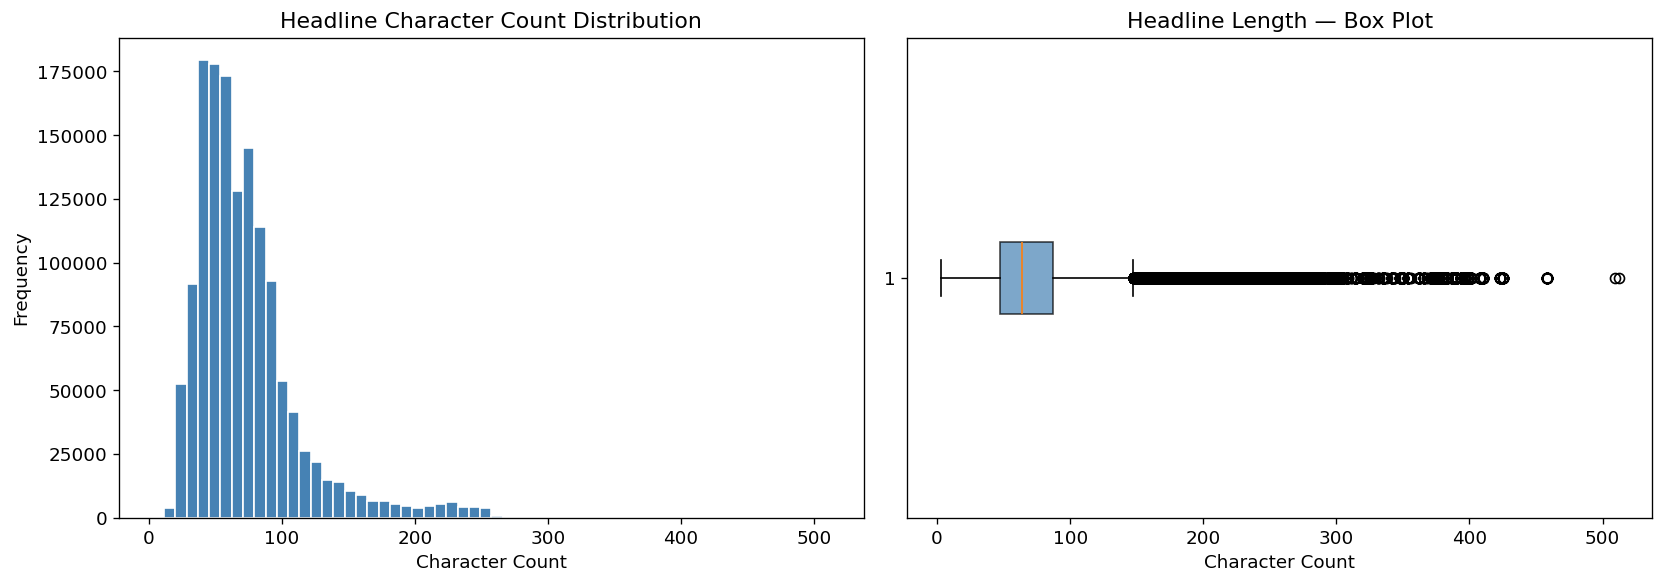

In [4]:
fig = plot_headline_length_distribution(df, save_path=str(OUTPUT_DIR / 'headline_length_dist.png'))
plt.show()

## 2. Articles per Publisher

In [5]:
publisher_counts = articles_per_publisher(df, top_n=20)
print(f'Total unique publishers: {df["publisher"].nunique()}')
print('\nTop 20 publishers:')
print(publisher_counts.to_string())

Total unique publishers: 1034

Top 20 publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590


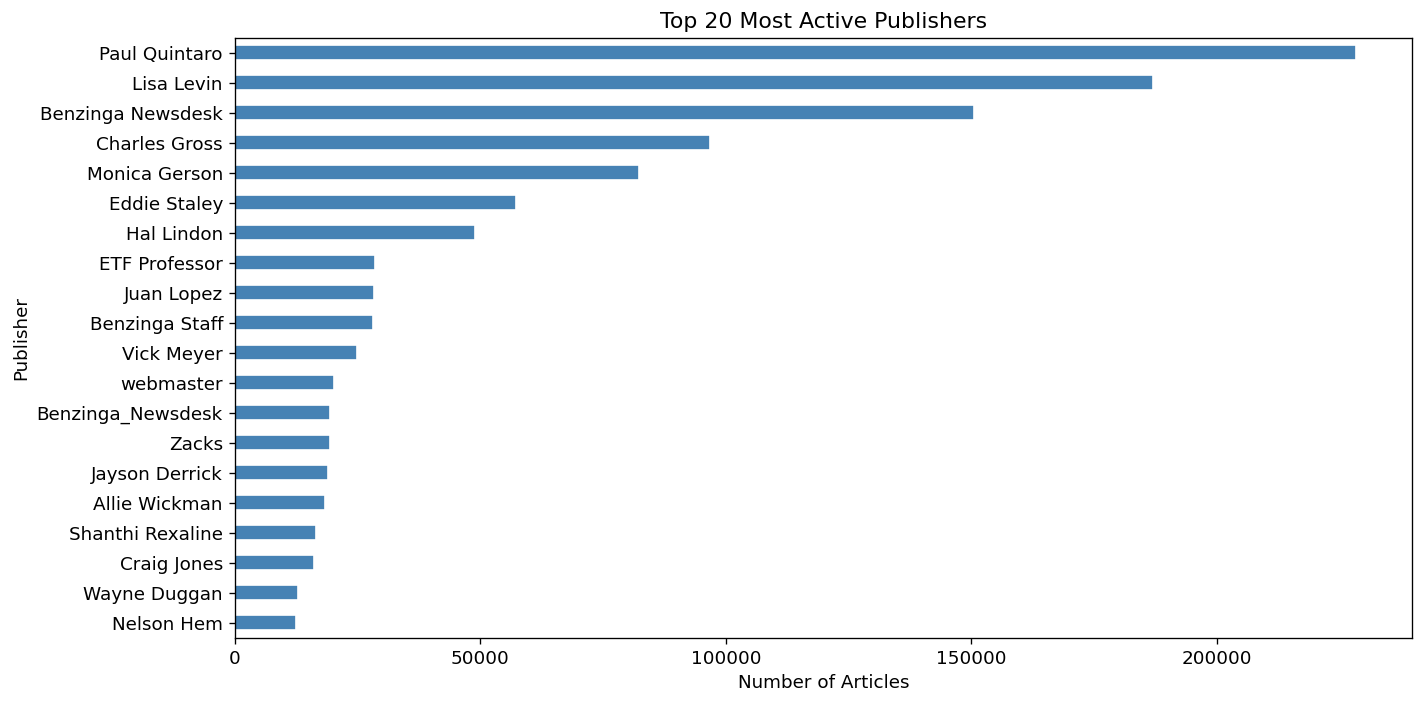

In [6]:
fig = plot_articles_per_publisher(df, top_n=20, save_path=str(OUTPUT_DIR / 'articles_per_publisher.png'))
plt.show()

## 3. Publication Volume Trends Over Time

In [7]:
weekly = publication_date_trends(df, freq='W')
print(f'Weekly trend — {len(weekly)} weeks')
print(f'Peak week: {weekly.idxmax().date()} ({weekly.max()} articles)')
print(f'Average per week: {weekly.mean():.0f}')

Weekly trend — 592 weeks
Peak week: 2020-03-15 (7587 articles)
Average per week: 2377


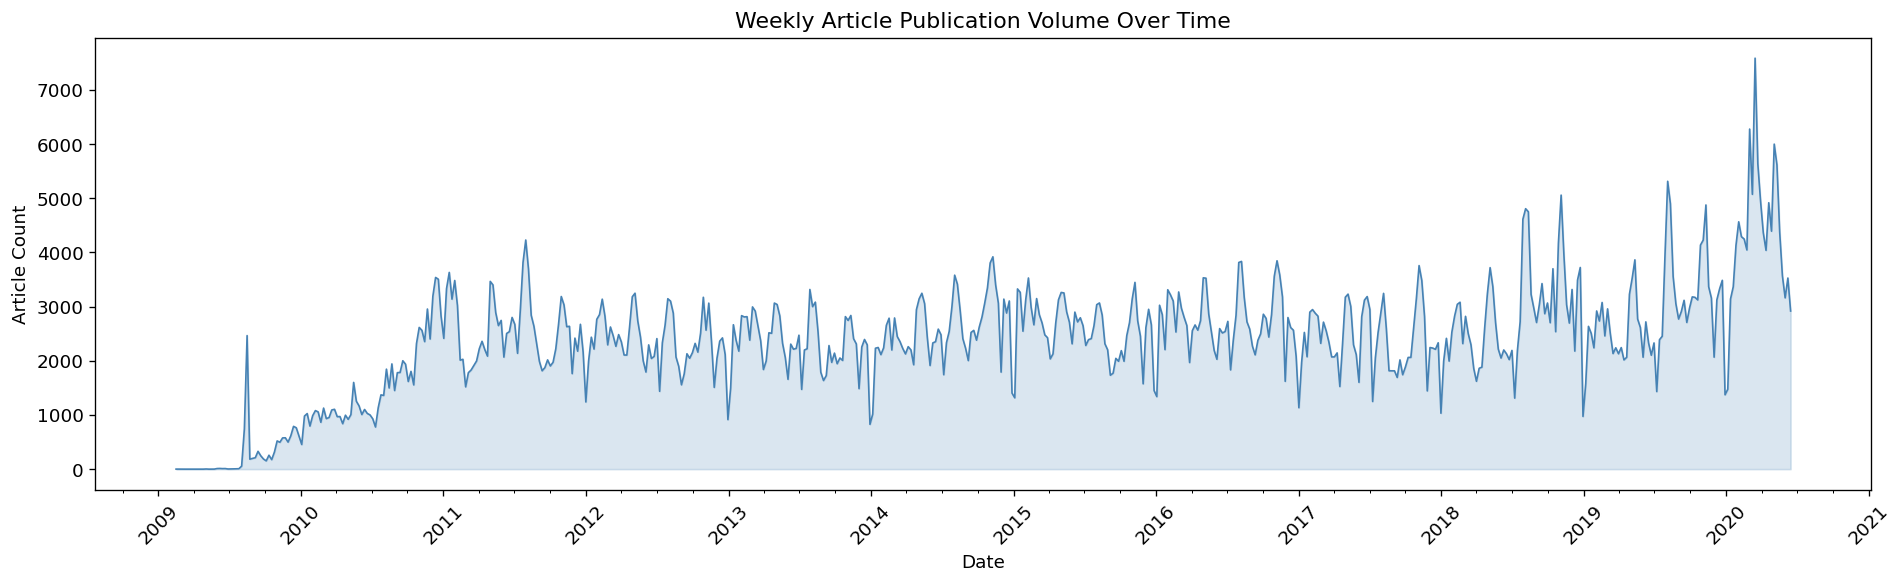

In [8]:
fig = plot_publication_trends(df, freq='W', save_path=str(OUTPUT_DIR / 'publication_trends_weekly.png'))
plt.show()

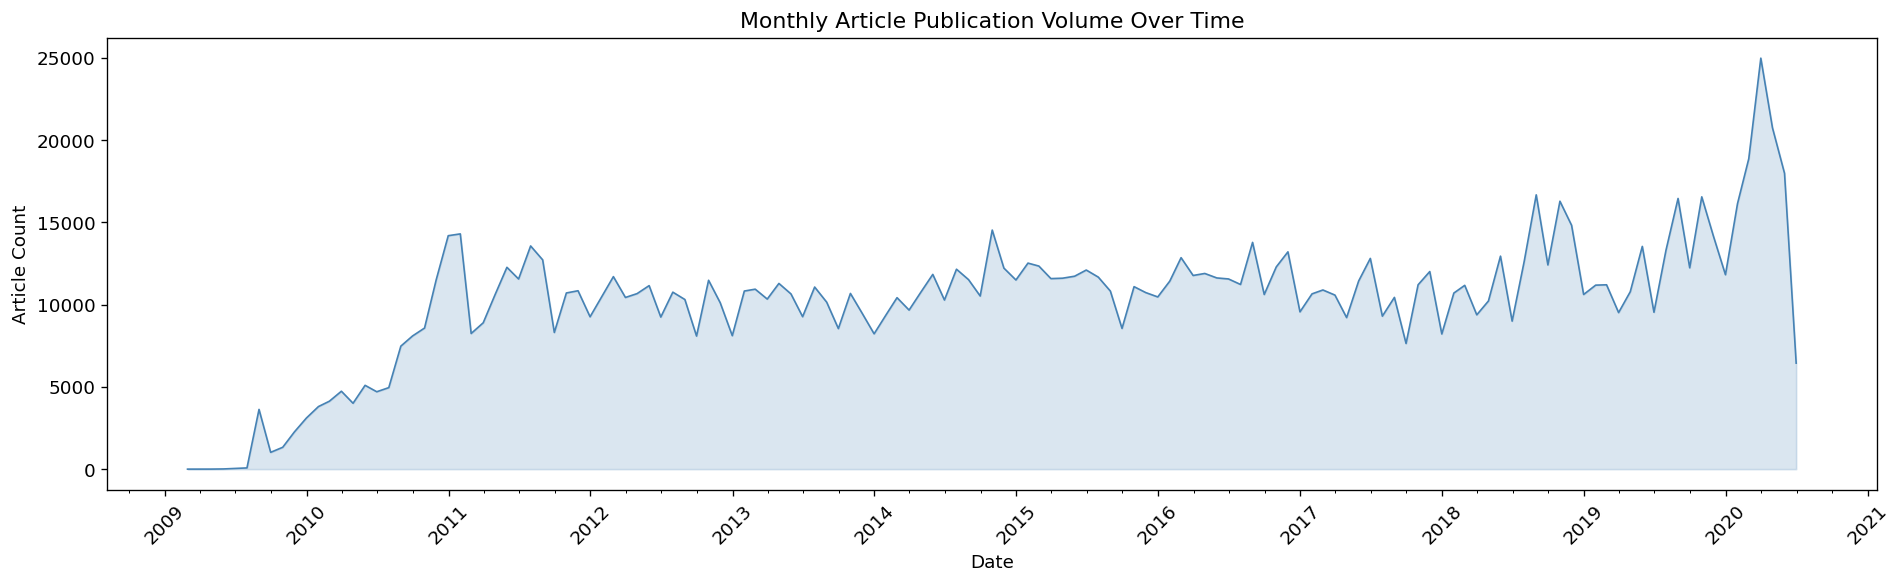

In [9]:
fig = plot_publication_trends(df, freq='ME', save_path=str(OUTPUT_DIR / 'publication_trends_monthly.png'))
plt.show()

### Top 10 Highest-Volume Days

In [10]:
top_days = top_publishing_days(df, top_n=10)
print('Days with the most published articles:')
print(top_days.to_string(index=False))

Days with the most published articles:
      date  article_count
2020-03-12           2739
2020-02-28           1620
2020-03-19           1594
2020-02-27           1567
2020-03-06           1428
2020-05-07           1396
2020-03-23           1390
2020-04-29           1389
2020-03-11           1384
2020-04-30           1327


In [ ]:
# ── 1. Top keywords by raw frequency (unigrams) ──────────────────────────────
unigrams = top_count_terms(df, top_n=20, ngram_range=(1, 1))
print("Top 20 keywords (count):")
print(unigrams.to_string())

In [ ]:
fig = plot_top_terms(unigrams, title="Top 20 Keywords in Headlines (Count)",
                     save_path=str(OUTPUT_DIR / "top_keywords.png"))
plt.show()

In [ ]:
# ── 2. Top bigrams by raw frequency ──────────────────────────────────────────
bigrams = top_count_terms(df, top_n=20, ngram_range=(2, 2))
print("Top 20 bigrams (count):")
print(bigrams.to_string())

fig = plot_top_terms(bigrams, title="Top 20 Bigrams in Headlines (Count)",
                     save_path=str(OUTPUT_DIR / "top_bigrams.png"))
plt.show()

## 4. NLP — Keywords, Phrases & Topic Modeling

In [ ]:
# ── 3. TF-IDF — distinctive terms ────────────────────────────────────────────
tfidf_terms = top_tfidf_terms(df, top_n=20, ngram_range=(1, 2))
print("Top 20 terms by mean TF-IDF (frequent AND distinctive):")
print(tfidf_terms.round(4).to_string())

fig = plot_top_terms(tfidf_terms, title="Top 20 Terms by Mean TF-IDF Score",
                     save_path=str(OUTPUT_DIR / "top_tfidf.png"))
plt.show()

In [ ]:
# ── 4. Financial phrase frequency ────────────────────────────────────────────
phrase_counts = financial_phrase_counts(df)
print("Financial phrase occurrences in headlines:")
print(phrase_counts[phrase_counts > 0].to_string())

fig = plot_financial_phrases(df, save_path=str(OUTPUT_DIR / "financial_phrases.png"))
plt.show()

In [ ]:
# ── 5. LDA topic modeling (stratified sample) ────────────────────────────────
topics = lda_topics(df, n_topics=8, top_words=10, sample_n=100_000)
print("LDA Topics (stratified sample across all months):")
for t in topics:
    print(f"  Topic {t['topic']}: {', '.join(t['words'])}")

fig = plot_lda_topics(topics, save_path=str(OUTPUT_DIR / "lda_topics.png"))
plt.show()

## 5. Time Series — Publication Volume & Publishing Hours

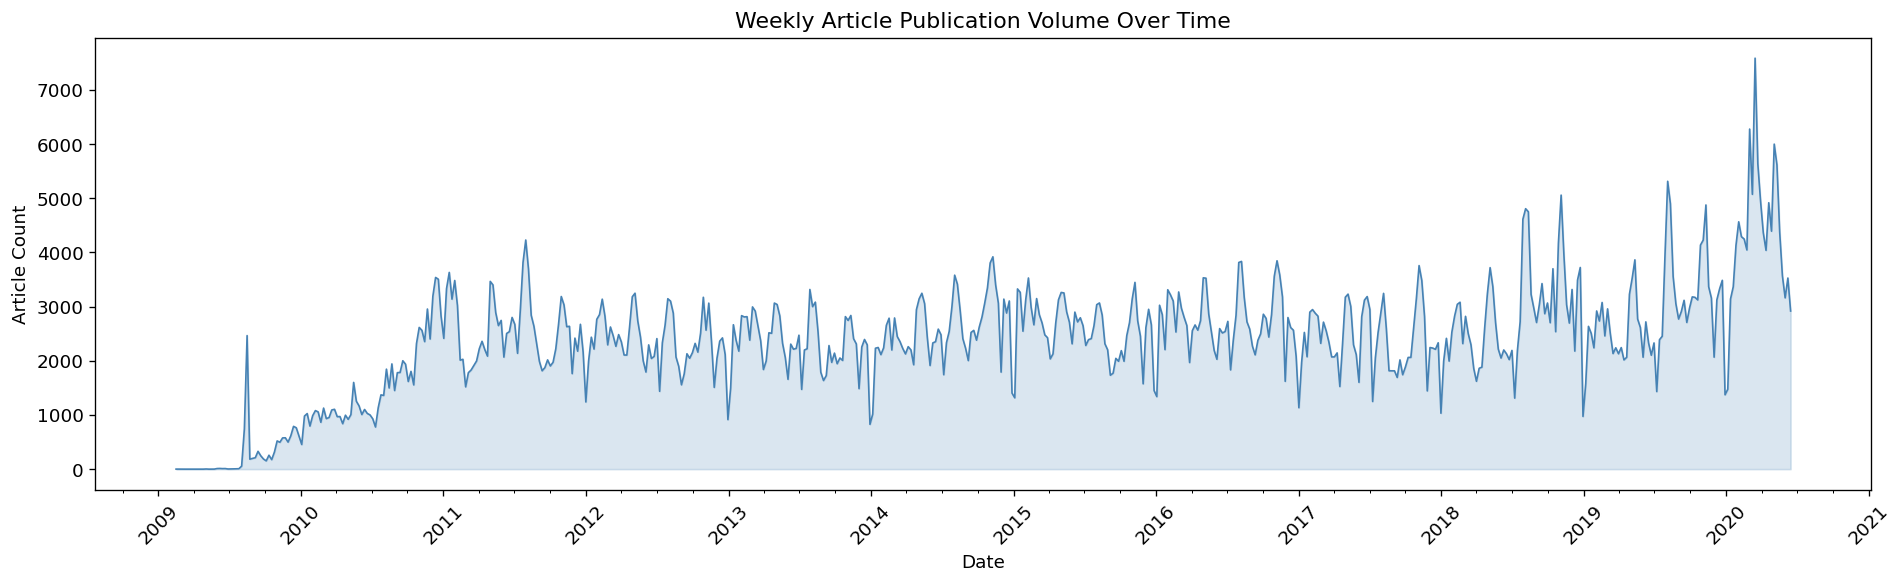

In [15]:
from src.eda import plot_publishing_hours, publishing_hour_distribution

fig = plot_publication_trends(df, freq="W",
                              save_path=str(OUTPUT_DIR / "publication_trends_weekly.png"))
plt.show()

In [ ]:
fig = plot_publication_trends(df, freq="W",
                              save_path=str(OUTPUT_DIR / "publication_trends_weekly.png"))
plt.show()

## 6. Publisher Analysis

In [17]:
from src.eda import extract_publisher_domains, plot_publisher_domains, publisher_coverage_profile

print(f"Total unique publishers: {df['publisher'].nunique()}")
email_pubs = df[df["publisher"].str.contains("@", na=False)]
print(f"Email-format publishers: {email_pubs['publisher'].nunique()}")
print(f"Name-format publishers:  {df['publisher'].nunique() - email_pubs['publisher'].nunique()}")

Total unique publishers: 1034
Email-format publishers: 18
Name-format publishers:  1016


In [ ]:
print(f"Total unique publishers: {df['publisher'].nunique()}")
email_pubs = df[df["publisher"].str.contains("@", na=False)]
print(f"Email-format publishers: {email_pubs['publisher'].nunique()}")
print(f"Name-format publishers:  {df['publisher'].nunique() - email_pubs['publisher'].nunique()}")

In [19]:
domains = extract_publisher_domains(df)
print(f"Unique email domains: {len(domains)}")
print("\nTop 15 domains:")
print(domains.head(15).to_string())

Unique email domains: 8

Top 15 domains:
0
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1


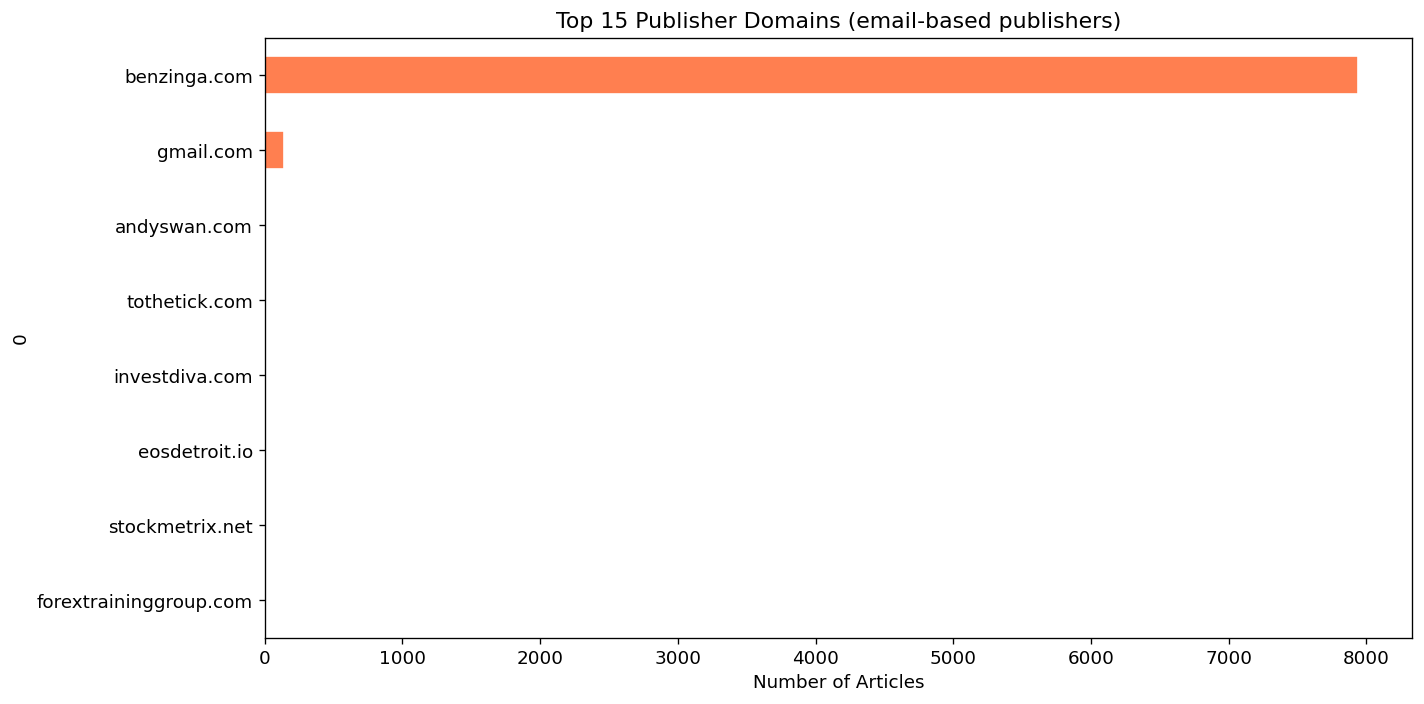

In [20]:
fig = plot_publisher_domains(df, top_n=15,
                            save_path=str(OUTPUT_DIR / "publisher_domains.png"))
plt.show()

In [21]:
profile = publisher_coverage_profile(df, top_n=10)
print("Publisher coverage profiles:")
print(profile.to_string(index=False))

Publisher coverage profiles:
        publisher  articles  unique_stocks first_date  last_date
    Paul Quintaro    228373           4703 2011-05-17 2018-06-07
       Lisa Levin    186979           4640 2010-07-30 2020-06-11
Benzinga Newsdesk    150484           4049 2015-01-15 2020-06-11
    Charles Gross     96732           4181 2011-11-08 2020-06-11
    Monica Gerson     82380           4012 2009-09-22 2017-10-03
     Eddie Staley     57254           4466 2011-06-27 2018-08-08
       Hal Lindon     49047           4474 2013-05-14 2019-10-07
    ETF Professor     28489           1891 2009-10-22 2020-06-11
       Juan Lopez     28438           2883 2011-12-13 2014-07-30
   Benzinga Staff     28114           3233 2009-07-27 2020-04-02
